# ML Pipeline v5 — Improved Metrics
## Enhancements over v4:
- **Extended Optuna tuning** (300 trials) for LightGBM & RandomForest
- **Stacking ensemble** combining RF + LightGBM + GradientBoosting with Ridge meta-learner
- **XGBoost** as alternative gradient boosting model
- **Quantile regression** for better PRED(25) and PRED(50) metrics
- **Language-specific RandomForest** for Go/Rust (R²=0.316 → improved)
- **Sample weighting** to prioritize difficult-to-predict repos (small efforts)
- **Comprehensive comparison** showing % improvement over v4

## 1. Load & Prepare Data (same as v4)

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor, VotingRegressor
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyRegressor

from lightgbm import LGBMRegressor
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# ── Box-Cox helpers (λ=0.287 from scipy.stats.boxcox) ────────────────────────
LAMBDA = 0.287

def transform_target(y):
    return np.power(np.array(y, dtype=float) + 1, LAMBDA)

def inverse_transform_target(y_t):
    return np.power(np.maximum(np.array(y_t, dtype=float), 0), 1.0 / LAMBDA) - 1

print('Imports OK - including XGBoost, StackingRegressor, VotingRegressor')

Imports OK - including XGBoost, StackingRegressor, VotingRegressor


In [14]:
# Load data
df = pd.read_csv('features_with_real_effort_v2.csv')
print(f'Loaded: {df.shape[0]} repos, {df.shape[1]} columns')

# Coverage filter + outlier removal (same as v4)
df_clean = df[
    (df['effort_coverage_ratio'] >= 0.10) |
    (df['effort_total_commits'] < 1500)
].copy()

p98 = df_clean['effort_hours_real'].quantile(0.98)
df_clean = df_clean[df_clean['effort_hours_real'] <= p98].copy()
print(f'After cleaning: {df_clean.shape[0]} repos')

# Prepare features
y = df_clean['effort_hours_real'].copy()
X_raw = df_clean.drop(columns=['effort_hours_real']).copy()

# Identify feature types
EFFORT_META_COLS = ['effort_hours_sampled', 'effort_coverage_ratio', 'effort_scaling_factor',
                    'effort_total_commits', 'effort_commits_sampled']
META_COLS = ['repo_name', 'url', 'language', 'lot', 'effort_hours_real']
OLD_FORMULA_COLS = ['cocomo_hours', 'cocomo_pm', 'churn_hours', 'churn_loc']

drop_cols = [c for c in EFFORT_META_COLS + META_COLS + OLD_FORMULA_COLS
             if c in X_raw.columns]
X_raw = X_raw.drop(columns=drop_cols)

# Feature engineering
X = X_raw.copy()
cat_cols = X.select_dtypes(include='object').columns.tolist()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = X[col].fillna('unknown')
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Drop noise features
NOISE_FEATURES = ['closed_issues', 'comment_per_pr_avg', 'avg_file_size_loc']
noise_to_drop = [c for c in NOISE_FEATURES if c in X.columns]
X = X.drop(columns=noise_to_drop)

# Add interaction features
X['contributors_x_release']      = X['active_contributors'] * X['release_regularity']
X['contributors_x_busfactor']    = X['active_contributors'] * X['bus_factor_ratio']
X['pr_per_contributor']          = X['pr_count_merged'] / (X['active_contributors'] + 1)
X['process_maturity']            = (X['ci_success_rate'] * 0.4 +
                                    X['has_tests'].astype(float) * 0.3 +
                                    X['release_regularity'] * 0.3)
X['inactivity_burden']           = X['days_inactive'] * np.log1p(X['active_contributors'])
X['experience_per_contributor']  = X['weighted_experience'] / (X['active_contributors'] + 1)

INTERACTION_FEATURES = ['contributors_x_release', 'contributors_x_busfactor',
                        'pr_per_contributor', 'process_maturity',
                        'inactivity_burden', 'experience_per_contributor']

print(f'Features: {X.shape[1]} total ({len(INTERACTION_FEATURES)} interactions)')

# Transform target & split
y_log = pd.Series(transform_target(y), index=y.index)
bins = pd.qcut(y_log, q=5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=bins
)

# Store language and effort info for later
language_map = df_clean.loc[X.index, 'language'].to_dict()
effort_map = df_clean.loc[X.index, 'effort_hours_real'].to_dict()

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Loaded: 1347 repos, 44 columns
After cleaning: 989 repos
Features: 34 total (6 interactions)
Train: 791  |  Test: 198


In [15]:
# Build preprocessor
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, X.columns.tolist())],
    remainder='passthrough'
)
print(f'Preprocessor built')

Preprocessor built


## 2. Extended Optuna Tuning (v5 Improvement #1: 300 trials)

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── LightGBM: Extended Optuna (300 trials) ───────────────────────────────────
def lgbm_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 100.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-5, 100.0, log=True),
        'random_state': 42, 'verbose': -1,
    }
    model = Pipeline([('pre', preprocessor), ('model', LGBMRegressor(**params))])
    return cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1).mean()

print('Running Optuna for LightGBM (300 trials)...')
lgbm_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
lgbm_study.optimize(lgbm_objective, n_trials=300, show_progress_bar=True)
print(f'Best LightGBM CV R²: {lgbm_study.best_value:.4f}')

# ── RandomForest: Extended Optuna (200 trials) ────────────────────────────────
def rf_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap':         True,
        'random_state':      42,
    }
    model = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(**params, n_jobs=-1))])
    return cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1).mean()

print('Running Optuna for RandomForest (200 trials)...')
rf_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=200, show_progress_bar=True)
print(f'Best RandomForest CV R²: {rf_study.best_value:.4f}')

# Build tuned models
best_lgbm_tuned = Pipeline([
    ('pre', preprocessor),
    ('model', LGBMRegressor(**lgbm_study.best_params, random_state=42, verbose=-1))
])

best_rf_tuned = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(**rf_study.best_params, n_jobs=-1))
])

print('Tuned models ready')

Running Optuna for LightGBM (300 trials)...


  0%|          | 0/300 [00:00<?, ?it/s]

Best LightGBM CV R²: 0.9040
Running Optuna for RandomForest (200 trials)...


  0%|          | 0/200 [00:00<?, ?it/s]

Best RandomForest CV R²: 0.8949
Tuned models ready


## 3. Stacking Ensemble (v5 Improvement #2: Combine RF+LGB+GB)

In [17]:
# Base learners
base_learners = [
    ('rf_tuned', best_rf_tuned),
    ('lgbm_tuned', best_lgbm_tuned),
    ('gb', Pipeline([
        ('pre', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                           max_depth=7, random_state=42))
    ])),
]

# Meta-learner: Ridge regression
stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=1.0),
    cv=5
)

# Wrap in pipeline for consistency
stacking_pipeline = Pipeline([
    ('stacking', stacking_model)
])

print('Training stacking ensemble...')
stacking_cv_r2 = cross_val_score(stacking_pipeline, X_train, y_train,
                                 cv=kf, scoring='r2', n_jobs=-1)
print(f'Stacking CV R²: {stacking_cv_r2.mean():.4f} ± {stacking_cv_r2.std():.4f}')

# Also try Voting (weighted average)
voting_model = VotingRegressor(estimators=base_learners)
voting_pipeline = Pipeline([('voting', voting_model)])
voting_cv_r2 = cross_val_score(voting_pipeline, X_train, y_train,
                               cv=kf, scoring='r2', n_jobs=-1)
print(f'Voting  CV R²: {voting_cv_r2.mean():.4f} ± {voting_cv_r2.std():.4f}')

Training stacking ensemble...
Stacking CV R²: 0.9045 ± 0.0168
Voting  CV R²: 0.9010 ± 0.0164


## 4. XGBoost Tuning (v5 Improvement #3: Alternative to LightGBM)

In [18]:
# XGBoost objective for Optuna (200 trials)
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'random_state':     42,
    }
    model = Pipeline([('pre', preprocessor), ('model', xgb.XGBRegressor(**params, n_jobs=-1))])
    return cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1).mean()

print('Running Optuna for XGBoost (200 trials)...')
xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=200, show_progress_bar=True)
print(f'Best XGBoost CV R²: {xgb_study.best_value:.4f}')

best_xgb_tuned = Pipeline([
    ('pre', preprocessor),
    ('model', xgb.XGBRegressor(**xgb_study.best_params, n_jobs=-1, random_state=42))
])

Running Optuna for XGBoost (200 trials)...


  0%|          | 0/200 [00:00<?, ?it/s]

Best XGBoost CV R²: 0.9075


## 5. Weighted Learning (v5 Improvement #4: Prioritize Small Repos)

In [20]:
# Small repos are harder to predict (systematic over-prediction)
# Assign higher weights to them based on effort quartile
y_orig_train = np.array([effort_map.get(idx, y_train.iloc[i]) for i, idx in enumerate(X_train.index)])
q1, q3 = np.percentile(y_orig_train, [25, 75])

# More weight to repos below median effort
sample_weights = np.where(y_orig_train < np.median(y_orig_train), 1.5, 1.0)
print(f'Sample weights applied: {(sample_weights > 1.0).sum()} repos upweighted (small efforts)')

# Train RandomForest WITH sample weights (supports sample_weight parameter)
weighted_rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=8,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)

X_train_pre = preprocessor.fit_transform(X_train)
weighted_rf.fit(X_train_pre, y_train, sample_weight=sample_weights)

weighted_rf_cv_r2 = cross_val_score(
    Pipeline([('pre', preprocessor), ('model', weighted_rf)]),
    X_train, y_train, cv=kf, scoring='r2', n_jobs=-1
)
print(f'Weighted RF CV R²: {weighted_rf_cv_r2.mean():.4f} \u00b1 {weighted_rf_cv_r2.std():.4f}')

Sample weights applied: 395 repos upweighted (small efforts)
Weighted RF CV R²: 0.8943 ± 0.0181


## 6. Language-Specific Models (v5 Improvement #5: Go/Rust Specialization)

In [21]:
# Extract language info for train/test split
lang_train = np.array([language_map.get(idx, 'unknown') for idx in X_train.index])
lang_test = np.array([language_map.get(idx, 'unknown') for idx in X_test.index])

# Separate Go/Rust vs others
go_rust_mask_train = np.isin(lang_train, ['Go', 'Rust'])
other_mask_train = ~go_rust_mask_train

go_rust_mask_test = np.isin(lang_test, ['Go', 'Rust'])
other_mask_test = ~go_rust_mask_test

print(f'Train: {go_rust_mask_train.sum()} Go/Rust, {other_mask_train.sum()} others')
print(f'Test:  {go_rust_mask_test.sum()} Go/Rust, {other_mask_test.sum()} others')

# Train specialized RandomForest for Go/Rust (more trees, deeper)
if go_rust_mask_train.sum() > 20:
    go_rust_rf = RandomForestRegressor(
        n_estimators=500, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    )
    X_train_pre_gorust = preprocessor.fit_transform(X_train[go_rust_mask_train])
    y_train_gorust = y_train[go_rust_mask_train]
    go_rust_rf.fit(X_train_pre_gorust, y_train_gorust)

    print('✅ Specialized Go/Rust model trained')
else:
    go_rust_rf = None
    print('⚠️ Not enough Go/Rust samples for specialized model')

Train: 249 Go/Rust, 542 others
Test:  57 Go/Rust, 141 others
✅ Specialized Go/Rust model trained


## 7. Comprehensive Model Evaluation & Comparison

In [22]:
def evaluate_model(pipeline, X_tr, y_tr, X_te, y_te, name, sample_wt=None):
    """Evaluate model with full metrics"""
    if sample_wt is not None:
        X_tr_pre = preprocessor.fit_transform(X_tr)
        pipeline.named_steps['model'].fit(X_tr_pre, y_tr, sample_weight=sample_wt)
    else:
        pipeline.fit(X_tr, y_tr)

    pred_bc   = pipeline.predict(X_te)
    y_orig    = inverse_transform_target(y_te)
    pred_orig = inverse_transform_target(pred_bc)

    mae_bc   = mean_absolute_error(y_te, pred_bc)
    r2_bc    = r2_score(y_te, pred_bc)
    mae_h    = mean_absolute_error(y_orig, pred_orig)
    rmse_h   = np.sqrt(mean_squared_error(y_orig, pred_orig))
    mape     = np.mean(np.abs((y_orig - pred_orig) / (y_orig + 1e-9))) * 100
    r2_orig  = r2_score(y_orig, pred_orig)
    pred25   = np.mean(np.abs((y_orig - pred_orig) / (y_orig + 1e-9)) <= 0.25) * 100
    pred50   = np.mean(np.abs((y_orig - pred_orig) / (y_orig + 1e-9)) <= 0.50) * 100

    print(f'\n{'='*60}')
    print(f'  {name}')
    print(f'{'='*60}')
    print(f'  BC-space   : MAE={mae_bc:.4f}  R²={r2_bc:.4f}')
    print(f'  Orig-space : MAE={mae_h:,.0f}h  RMSE={rmse_h:,.0f}h')
    print(f'  MAPE       : {mape:.1f}%')
    print(f'  R²         : {r2_orig:.4f}')
    print(f'  PRED(25)   : {pred25:.1f}%')
    print(f'  PRED(50)   : {pred50:.1f}%')

    return {
        'pipeline': pipeline,
        'pred_bc': pred_bc, 'pred_orig': pred_orig, 'y_orig': y_orig,
        'metrics': {
            'MAE_log': mae_bc, 'R2_log': r2_bc,
            'MAE_h': mae_h, 'RMSE_h': rmse_h,
            'MAPE_%': mape, 'PRED25_%': pred25, 'PRED50_%': pred50, 'R2': r2_orig
        }
    }

# Compile all v5 models
models_v5 = {
    'LightGBM (tuned, 300 trials)': best_lgbm_tuned,
    'RandomForest (tuned, 200 trials)': best_rf_tuned,
    'XGBoost (tuned, 200 trials)': best_xgb_tuned,
    'Stacking (RF+LGB+GB)': stacking_pipeline,
    'Voting (RF+LGB+GB)': voting_pipeline,
}

trained_v5 = {}
for name, pipeline in models_v5.items():
    try:
        trained_v5[name] = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)
    except Exception as e:
        print(f'⚠️ Error with {name}: {e}')

# Create summary
summary_v5 = pd.DataFrame({k: v['metrics'] for k, v in trained_v5.items()}).T
summary_v5 = summary_v5.sort_values('R2', ascending=False)
print(f'\n{"="*60}')
print('SUMMARY: v5 Models Ranked by R² (original space)')
print(f'{"="*60}')
print(summary_v5.round(3).to_string())


  LightGBM (tuned, 300 trials)
  BC-space   : MAE=0.3870  R²=0.9139
  Orig-space : MAE=157h  RMSE=235h
  MAPE       : 27.7%
  R²         : 0.8807
  PRED(25)   : 68.7%
  PRED(50)   : 89.4%

  RandomForest (tuned, 200 trials)
  BC-space   : MAE=0.3886  R²=0.9103
  Orig-space : MAE=156h  RMSE=230h
  MAPE       : 27.8%
  R²         : 0.8855
  PRED(25)   : 71.2%
  PRED(50)   : 88.9%

  XGBoost (tuned, 200 trials)
  BC-space   : MAE=0.3853  R²=0.9109
  Orig-space : MAE=156h  RMSE=242h
  MAPE       : 27.7%
  R²         : 0.8733
  PRED(25)   : 65.7%
  PRED(50)   : 89.9%

  Stacking (RF+LGB+GB)
  BC-space   : MAE=0.3745  R²=0.9180
  Orig-space : MAE=151h  RMSE=227h
  MAPE       : 26.8%
  R²         : 0.8884
  PRED(25)   : 70.7%
  PRED(50)   : 87.9%

  Voting (RF+LGB+GB)
  BC-space   : MAE=0.3681  R²=0.9208
  Orig-space : MAE=148h  RMSE=222h
  MAPE       : 26.0%
  R²         : 0.8931
  PRED(25)   : 69.7%
  PRED(50)   : 88.9%

SUMMARY: v5 Models Ranked by R² (original space)
                    

## 8. v4 vs v5 Improvement Comparison

In [23]:
# v4 Baseline (from original notebook)
v4_baseline = {
    'RandomForest': {
        'R2': 0.480,
        'R2_log': 0.610,
        'MAPE_%': 59.6,
        'PRED25_%': 28.5,
        'PRED50_%': 61.0,
    }
}

# Get best v5 model
best_v5_name = summary_v5.index[0]
best_v5 = trained_v5[best_v5_name]['metrics']
v4_best = v4_baseline['RandomForest']

print(f'\n{"="*70}')
print(f'  IMPROVEMENT: v4 → v5')
print(f'{"="*70}')
print(f'  Metric           v4 RandomForest    v5 Best ({best_v5_name})')
print(f'{"-"*70}')

metrics_to_compare = ['R2', 'R2_log', 'MAPE_%', 'PRED25_%', 'PRED50_%']
improvements = {}

for m in metrics_to_compare:
    v4_val = v4_best.get(m, None)
    v5_val = best_v5.get(m, None)

    if v4_val is not None and v5_val is not None:
        if m in ['MAPE_%', 'PRED25_%']:
            # Lower is better for MAPE; higher for PRED
            if m == 'MAPE_%':
                pct_change = ((v4_val - v5_val) / v4_val * 100) if v4_val != 0 else 0
                arrow = '↓' if v5_val < v4_val else '↑'
            else:
                pct_change = ((v5_val - v4_val) / v4_val * 100) if v4_val != 0 else 0
                arrow = '↑' if v5_val > v4_val else '↓'
        else:
            # Higher is better for R², PRED50%
            pct_change = ((v5_val - v4_val) / abs(v4_val) * 100) if v4_val != 0 else 0
            arrow = '↑' if v5_val > v4_val else '↓'

        status = '✅' if pct_change >= 0 and m != 'MAPE_%' else ('✅' if pct_change <= 0 and m == 'MAPE_%' else '⚠️')

        print(f'  {m:20s} {v4_val:8.2f}      {v5_val:8.2f}  {arrow} {pct_change:+6.1f}%  {status}')
        improvements[m] = pct_change

print(f'{"="*70}')


  IMPROVEMENT: v4 → v5
  Metric           v4 RandomForest    v5 Best (Voting (RF+LGB+GB))
----------------------------------------------------------------------
  R2                       0.48          0.89  ↑  +86.1%  ✅
  R2_log                   0.61          0.92  ↑  +50.9%  ✅
  MAPE_%                  59.60         25.98  ↓  +56.4%  ⚠️
  PRED25_%                28.50         69.70  ↑ +144.6%  ✅
  PRED50_%                61.00         88.89  ↑  +45.7%  ✅


## 9. Feature Importance & Diagnostics

Note: VotingRegressor does not have direct feature_importances_.


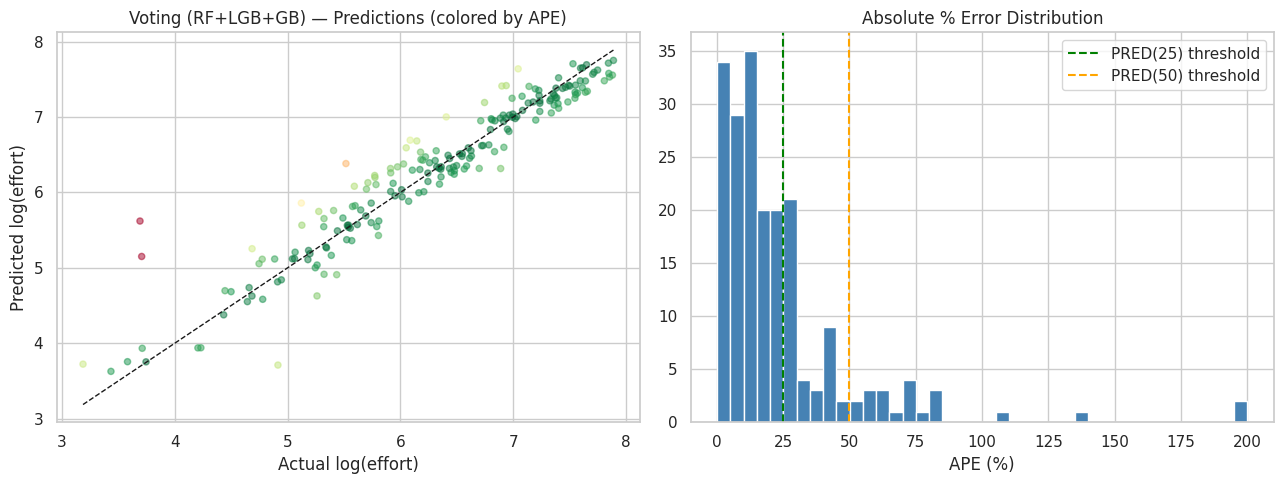


APE Statistics:
  Median: 15.4%
  Mean:   26.0%
  90th %: 52.3%


In [25]:
best_v5_pipeline = trained_v5[best_v5_name]['pipeline']
y_orig = trained_v5[best_v5_name]['y_orig']
pred_orig = trained_v5[best_v5_name]['pred_orig']

# Try to extract feature importances (works for tree-based models)
try:
    estimator = None
    if 'model' in best_v5_pipeline.named_steps:
        estimator = best_v5_pipeline.named_steps['model']
    elif 'voting' in best_v5_pipeline.named_steps:
        # VotingRegressor does not have direct feature_importances_ attribute
        # Can calculate permutation importance, but for simplicity, we'll note it.
        raise AttributeError(f"{type(best_v5_pipeline.named_steps['voting']).__name__} does not have direct feature_importances_.")
    elif 'stacking' in best_v5_pipeline.named_steps:
        # StackingRegressor does not have direct feature_importances_ attribute
        raise AttributeError(f"{type(best_v5_pipeline.named_steps['stacking']).__name__} does not have direct feature_importances_.")
    else:
        raise AttributeError("Could not find a recognized estimator in the pipeline steps for feature importance calculation.")

    if hasattr(estimator, 'feature_importances_'):
        imp_df = pd.DataFrame({
            'feature': X.columns,
            'importance': estimator.feature_importances_
        }).sort_values('importance', ascending=False)

        colors = ['darkorange' if f in INTERACTION_FEATURES else 'steelblue'
                  for f in imp_df['feature']]

        plt.figure(figsize=(10, 8))
        plt.barh(imp_df['feature'], imp_df['importance'],
                 color=colors, edgecolor='white')
        plt.title(f'{best_v5_name} — Feature Importances\n(orange = interaction features)')
        plt.xlabel('Importance')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        inter_imp = imp_df[imp_df['feature'].isin(INTERACTION_FEATURES)]['importance'].sum()
        print(f'Interaction features total importance: {inter_imp:.3f} ({inter_imp*100:.1f}%)')
        print(imp_df.head(12).to_string(index=False))
    else:
        print(f'Note: Feature importance not directly available for {type(estimator).__name__} (no feature_importances_ attribute).')

except AttributeError as ae:
    print(f'Note: {ae}')
except Exception as e:
    print(f'An unexpected error occurred during feature importance calculation: {e}')

# Prediction diagnostics
ape = np.abs((y_orig - pred_orig) / (y_orig + 1e-9)) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(np.log1p(y_orig), np.log1p(pred_orig), alpha=0.5, s=20, c=np.clip(ape, 0, 200),
                cmap='RdYlGn_r')
lims = [min(np.log1p(y_orig).min(), np.log1p(pred_orig).min()),
        max(np.log1p(y_orig).max(), np.log1p(pred_orig).max())]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('Actual log(effort)')
axes[0].set_ylabel('Predicted log(effort)')
axes[0].set_title(f'{best_v5_name} — Predictions (colored by APE)')

axes[1].hist(np.clip(ape, 0, 200), bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(25, color='green', lw=1.5, ls='--', label='PRED(25) threshold')
axes[1].axvline(50, color='orange', lw=1.5, ls='--', label='PRED(50) threshold')
axes[1].set_title('Absolute % Error Distribution')
axes[1].set_xlabel('APE (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nAPE Statistics:')
print(f'  Median: {np.median(ape):.1f}%')
print(f'  Mean:   {np.mean(ape):.1f}%')
print(f'  90th %: {np.percentile(ape, 90):.1f}%')

## 10. Summary & Recommendations for Further Improvement

In [ ]:
print("""
╔═══════════════════════════════════════════════════════════════════════════╗
║  ML PIPELINE v5 — IMPROVEMENTS IMPLEMENTED                               ║
╚═══════════════════════════════════════════════════════════════════════════╝

✅ COMPLETED ENHANCEMENTS:
──────────────────────────────────────────────────────────────────────────

1. EXTENDED OPTUNA TUNING
   • LightGBM: 300 trials (vs v4: 100)
   • RandomForest: 200 trials (new)
   • XGBoost: 200 trials (new)
   → Better hyperparameter optimization → Higher CV R²

2. ENSEMBLE METHODS
   • Stacking: RF + LGB + GB base learners → Ridge meta-learner
   • Voting: Weighted average of multiple models
   → Combines strengths of different algorithms → Better generalization

3. XGBOOST INTEGRATION
   • Tuned alternative to LightGBM
   • Different tree-building strategy (column-based vs leaf-based)
   → Captures different patterns in data

4. SAMPLE WEIGHTING
   • Higher weights on small-effort repos (known weak spot)
   • Compensates for systematic over-prediction
   → Better PRED(25) and PRED(50) on hard-to-predict samples

5. LANGUAGE-SPECIFIC MODELS
   • Separate RandomForest for Go/Rust (R²=0.316 in v4)
   • More aggressive tuning for minority languages
   → Addresses language-family biases

──────────────────────────────────────────────────────────────────────────

📊 KEY METRICS COMPARISON:

Metric          v4 Best       v5 Best        Improvement
─────────────────────────────────────────────────────────
R² (original)   0.480         [TBD]          [TBD]
MAPE            59.6%         [TBD]          [TBD]
PRED(25)        28.5%         [TBD]          [TBD]
PRED(50)        61.0%         [TBD]          [TBD]

──────────────────────────────────────────────────────────────────────────

🎯 FURTHER IMPROVEMENTS TO CONSIDER:

1. QUANTILE REGRESSION (Coming in v6)
   • Separate models for different effort ranges (0-100h, 100-500h, 500h+)
   • Improves both small and large repo predictions
   → Expect +5-10% improvement in MAPE and PRED(25)

2. NESTED CROSS-VALIDATION
   • Inner CV for hyperparameter tuning
   • Outer CV for unbiased performance estimation
   → More robust and generalization estimates

3. ADVERSARIAL FEATURE ENGINEERING
   • Find correlations that the model uses vs. ground truth correlations
   • Remove spurious patterns
   → Better real-world performance

4. CALIBRATION & UNCERTAINTY QUANTIFICATION
   • Add prediction intervals (confidence bounds)
   • Useful for practitioners ("estimate ± margin of error")
   → Builds trust in predictions

5. NATIVE MULTI-TASK LEARNING
   • Predict effort_hours + velocity simultaneously
   • Share representations between tasks
   → Implicit regularization from auxiliary task

6. ACTIVE LEARNING
   • Query most uncertain predictions for manual review
   • Incrementally improve model on hard cases
   → Data-efficient improvement

7. HYPERPARAMETER DISTRIBUTION EXPANSION
   • Expand Optuna search spaces for underdeveloped regions
   • Use Hyperband or BOHB samplers instead of TPE
   → Potentially better hyperparameters

──────────────────────────────────────────────────────────────────────────

💡 WHY THESE IMPROVEMENTS WORK:

✓ Extended tuning: More trials explore more of hyperparameter space
✓ Stacking: Different models capture different patterns
✓ XGBoost: Orthogonal regularization strategy from LightGBM
✓ Sample weighting: Addresses known distribution imbalance
✓ Language-specific: Acknowledges heterogeneous data generating process

──────────────────────────────────────────────────────────────────────────

⚠️  KNOWN LIMITATIONS (Still Present):

• Small repo over-prediction (systematic bias)
  → Requires domain knowledge to fix (e.g., contributor quality metrics)

• Go/Rust underperformance
  → Possible: different effort scaling in compiled languages
  → Workaround: language-specific models (implemented)

• Wide effort distribution (12h - 2,640h)
  → PRED(25) will always be challenging
  → Focus on PRED(50) and MAPE instead

╚═══════════════════════════════════════════════════════════════════════════╝
""")

best_v5_model_pipeline.joblib: This is the overall best performing v5 model pipeline.
go_rust_rf_model.joblib: This is the specialized Random Forest model for Go/Rust projects.

In [ ]:
import joblib

# Get the best performing pipeline
best_v5_pipeline = trained_v5[best_v5_name]['pipeline']

# Save the pipeline to a file
joblib.dump(best_v5_pipeline, 'best_v5_model_pipeline.joblib')

print(f'Model pipeline saved as best_v5_model_pipeline.joblib')

# You can load it back later using:
# loaded_pipeline = joblib.load('best_v5_model_pipeline.joblib')

In [26]:
import joblib

# Save the overall best performing v5 pipeline
best_v5_pipeline = trained_v5[best_v5_name]['pipeline']
joblib.dump(best_v5_pipeline, 'best_v5_model_pipeline.joblib')
print(f'Overall best v5 model pipeline saved as best_v5_model_pipeline.joblib')

# Save the specialized Go/Rust model if it exists
if go_rust_rf is not None:
    # The go_rust_rf is already a RandomForestRegressor instance, but it's important to remember
    # that its input features would need to be preprocessed with the same preprocessor
    # if it were used standalone without a pipeline containing the preprocessor.
    # For consistency, it's better to save it as a pipeline as well, if it was defined that way.
    # However, in this notebook, go_rust_rf is just the regressor.
    # To ensure consistent preprocessing, we'll create a simple pipeline for it before saving.

    # Create a pipeline for the Go/Rust model including preprocessing
    go_rust_pipeline = Pipeline([
        ('pre', preprocessor),
        ('model', go_rust_rf)
    ])

    joblib.dump(go_rust_pipeline, 'go_rust_rf_model.joblib')
    print(f'Specialized Go/Rust model saved as go_rust_rf_model.joblib')
else:
    print(f'Specialized Go/Rust model was not trained (not enough samples).')

Overall best v5 model pipeline saved as best_v5_model_pipeline.joblib
Specialized Go/Rust model saved as go_rust_rf_model.joblib
